In [5]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
from skimage.color import rgb2lab
from sklearn.cluster import KMeans
from scipy.ndimage import median_filter
import cv2

path = "imgs/frame.jpeg"

In [6]:
class WordfeudMap:

    # Fine-tuning multipliers around the base scale that fits template to target
    FINE_SCALES = [0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15]

    def __init__(self, img_path):
        self.img = self.load_img(img_path)
        self.board_offset = 10
        self.tile_size = self.img.shape[1] // 15
        self.x = np.arange(15) * self.tile_size
        self.y = np.arange(15) * self.tile_size

        self.colormap = {
            (41,  44,  49 ): 0,
            (234, 233, 222): 1,
            (117, 141, 95 ): 2,
            (53,  97,  138): 3,
            (184, 121, 51 ): 4,
            (130, 52,  49 ): 5,
        }
        self._color_keys = np.array(list(self.colormap.keys()), dtype=np.float32)
        self._color_vals = np.array(list(self.colormap.values()), dtype=np.int32)

        self.letter_data = {
            "A": {"antal": 7, "point": 1}, "B": {"antal": 4, "point": 3},
            "C": {"antal": 2, "point": 8}, "D": {"antal": 5, "point": 2},
            "E": {"antal": 9, "point": 1}, "F": {"antal": 3, "point": 3},
            "G": {"antal": 3, "point": 3}, "H": {"antal": 2, "point": 4},
            "I": {"antal": 4, "point": 3}, "J": {"antal": 2, "point": 4},
            "K": {"antal": 4, "point": 3}, "L": {"antal": 5, "point": 2},
            "M": {"antal": 3, "point": 4}, "N": {"antal": 7, "point": 1},
            "O": {"antal": 5, "point": 2}, "P": {"antal": 2, "point": 4},
            "R": {"antal": 7, "point": 1}, "S": {"antal": 6, "point": 2},
            "T": {"antal": 6, "point": 2}, "U": {"antal": 3, "point": 3},
            "V": {"antal": 3, "point": 4}, "X": {"antal": 1, "point": 8},
            "Y": {"antal": 2, "point": 4}, "Z": {"antal": 1, "point": 9},
            "Æ": {"antal": 2, "point": 4}, "Ø": {"antal": 2, "point": 4},
            "Å": {"antal": 2, "point": 4},
        }

        # Cache binarised templates (no border strip — templates are clean tiles)
        img_dir = "letters/"
        self._template_cache = {}
        for letter in self.letter_data:
            try:
                raw = np.array(Image.open(f"{img_dir}{letter.lower()}.png"))
                self._template_cache[letter] = self._to_binary(self._strip_border(raw, frac=0.10))
            except FileNotFoundError:
                pass
        
        self.map = self.img_to_map()

    # ── static helpers ────────────────────────────────────────────────────

    @staticmethod
    def _to_binary(img):
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]
        gray = rgb2lab(img)[:, :, 0]
        return (gray < 20).astype(np.uint8)

    @staticmethod
    def _strip_border(img, frac=0.08):
        """Crop outer border to remove dark board gaps."""
        H, W = img.shape[:2]
        dy, dx = int(H * frac), int(W * frac)
        return img[dy:H - dy, dx:W - dx]

    @staticmethod
    def _remove_border_fg(mask):
        """Remove foreground regions connected to the image border.

        The letter is always surrounded by light tile background, so it
        never touches the image edge.  But dark board gaps and coloured
        bonus squares at tile edges DO touch the border.  Dropping any
        connected component that touches the border removes them cleanly,
        regardless of colour.
        """
        h, w = mask.shape
        if h == 0 or w == 0:
            return mask
        # Build a 1-pixel-wide border mask
        border = np.zeros((h, w), dtype=np.uint8)
        border[0, :] = border[-1, :] = border[:, 0] = border[:, -1] = 1
        # Label connected components
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        out = mask.copy()
        for i in range(1, n_labels):
            if np.any((labels == i) & border):
                out[labels == i] = 0
        return out

    @staticmethod
    def _chamfer_score(a, b, tolerance=5.0):
        """Chamfer-distance-based similarity (higher = better)."""
        a_mask = a > 0
        b_mask = b > 0
        if not a_mask.any() or not b_mask.any():
            return 0.0
        dist_a = cv2.distanceTransform((~a_mask).astype(np.uint8), cv2.DIST_L2, 3)
        dist_b = cv2.distanceTransform((~b_mask).astype(np.uint8), cv2.DIST_L2, 3)
        d_ab = float(dist_b[a_mask].mean())
        d_ba = float(dist_a[b_mask].mean())
        return float(np.exp(-(d_ab + d_ba) / (2.0 * tolerance)))

    @staticmethod
    def _dice(a, b):
        inter = float(np.sum(a & b))
        denom = float(a.sum() + b.sum())
        return (2.0 * inter / denom) if denom else 0.0

    # ── image loading ─────────────────────────────────────────────────────

    def load_img(self, img_path):
        img = np.array(Image.open(img_path))[558:-250]
        kmeans = KMeans(n_clusters=8, random_state=0).fit(img.reshape(-1, 3))
        quantized = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
        return quantized.reshape(img.shape)

    # ── board colour map ──────────────────────────────────────────────────

    def closest_color(self, rgb):
        dists = np.linalg.norm(self._color_keys - np.array(rgb, dtype=np.float32), axis=1)
        return int(self._color_vals[np.argmin(dists)])

    def img_to_map(self):
        X, Y = np.meshgrid(self.x, self.y)
        X += self.board_offset
        points = np.column_stack([Y.ravel(), X.ravel()])
        rows, cols = zip(*points)
        samples = self.img[rows, cols, :].reshape(225, 3).astype(np.float32)
        dists = np.linalg.norm(
            samples[:, None, :] - self._color_keys[None, :, :], axis=2
        )
        labels = self._color_vals[np.argmin(dists, axis=1)]
        return labels.reshape(15, 15)

    # ── tile extraction ───────────────────────────────────────────────────

    def tile_from_coord(self, xi, yi):
        return self.img[
            self.x[xi] : self.x[xi] + self.tile_size - self.board_offset,
            self.y[yi] : self.y[yi] + self.tile_size,
        ]

    def available_letter_imgs(self):
        bottom_img = self.img[-155:-20, 20:-20]
        letter_W = 130
        tile_W = bottom_img.shape[1] // 7
        return [bottom_img[:, i * tile_W : i * tile_W + letter_W] for i in range(7)]

    def available_letters(self):
        letter_imgs = self.available_letter_imgs()
        letters = []
        for img in letter_imgs:
            letter = self.tile_to_text(img)
            letters.append(letter)
        return letters

    # ── core: template matching ───────────────────────────────────────────
    #
    # Simple strategy:
    #   1. Strip border from tile, binarise both (no foreground crop)
    #   2. Try a few uniform scales of the template
    #   3. At each scale, matchTemplate finds the best translation
    #   4. Chamfer score at the best position
    #   5. Return best across all scales

    @staticmethod
    def _match_score(tmpl_bw, target_bw):
        """Scale + translate matching with chamfer scoring."""
        tH, tW = target_bw.shape
        th, tw = tmpl_bw.shape
        tgt_f32 = target_bw.astype(np.float32)

        # Base scale: shrink/grow template so it fits inside target
        base_scale = min(tH / th, tW / tw)

        best_score = -1.0
        best_fitted = None

        for fine in WordfeudMap.FINE_SCALES:
            scale = base_scale * fine
            new_h = max(1, round(th * scale))
            new_w = max(1, round(tw * scale))

            # Template must fit inside target for matchTemplate
            if new_h > tH or new_w > tW:
                continue

            # Smooth resize + re-threshold
            resized = cv2.resize(
                tmpl_bw.astype(np.float32), (new_w, new_h),
                interpolation=cv2.INTER_LINEAR,
            )
            resized = (resized >= 0.5).astype(np.float32)

            if resized.sum() == 0:
                continue

            # Find best translation via cross-correlation
            match_map = cv2.matchTemplate(tgt_f32, resized, cv2.TM_CCORR)
            _, _, _, max_loc = cv2.minMaxLoc(match_map)
            bx, by = max_loc  # best (x, y) position

            # Place template at best position on target-sized canvas
            fitted = np.zeros((tH, tW), dtype=np.uint8)
            fitted[by:by + new_h, bx:bx + new_w] = resized.astype(np.uint8)

            # Score
            score = WordfeudMap._chamfer_score(fitted, target_bw)
            if score > best_score:
                best_score = score
                best_fitted = fitted

        if best_fitted is None:
            best_fitted = np.zeros((tH, tW), dtype=np.uint8)

        return best_score, best_fitted

    # ── public API ────────────────────────────────────────────────────────

    def tile_to_text(self, tile):
        if not self._template_cache:
            print("No templates loaded")
            return None

        tile_bw = self._remove_border_fg(self._to_binary(self._strip_border(tile)))

        best_match = None
        best_score = -1.0

        for letter, tmpl_bw in self._template_cache.items():
            score, _ = self._match_score(tmpl_bw, tile_bw)
            if score > best_score:
                best_score = score
                best_match = letter

        if best_match is not None:
            print(f"Best match: {best_match}  score={best_score:.4f}")
        else:
            print("No match found")

        return best_match

    def map_with_letters(self):
        board_map = self.map
        letter_map = np.full(board_map.shape, '', dtype=object)

        for xi in range(15):
            for yi in range(15):
                if board_map[xi, yi] == 1:  # Only attempt letter recognition on normal tiles
                    tile = self.tile_from_coord(xi, yi)
                    letter = self.tile_to_text(tile)
                    letter_map[xi, yi] = letter
                else:
                    letter_map[xi, yi] = str(self.map[yi, xi].item())  # Non-normal tiles are left blank

        return letter_map

WF = WordfeudMap(path)
mapped = WF.map_with_letters()
my_letters = WF.available_letters()

tile = WF.tile_from_coord(6, 8)
WF.tile_to_text(tile)

letter_imgs = WF.available_letter_imgs()
WF.tile_to_text(letter_imgs[2])

Best match: L  score=0.8264
Best match: U  score=0.9613
Best match: T  score=0.9052
Best match: Æ  score=0.8716
Best match: D  score=0.9769
Best match: N  score=0.9831
Best match: L  score=0.8106
Best match: J  score=0.6802
Best match: O  score=0.9381
Best match: H  score=0.9624
Best match: A  score=0.0000
Best match: N  score=0.9831


'N'

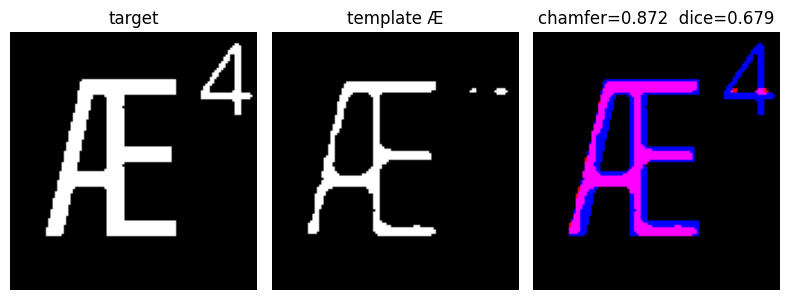

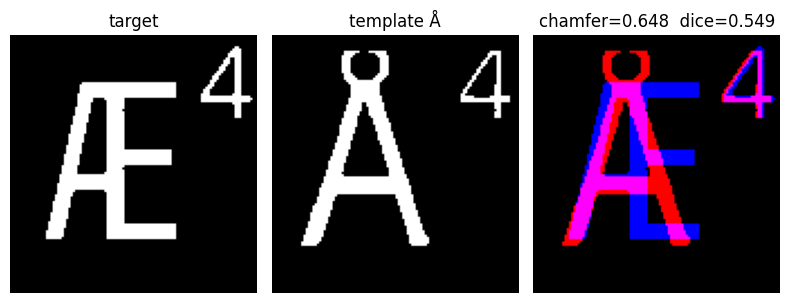

In [7]:
def overlay_letter(img, letters=("Æ", "Å")):
    target_bw = WordfeudMap._remove_border_fg(WordfeudMap._to_binary(WordfeudMap._strip_border(img)))
    H, W = target_bw.shape
    img_dir = "letters/"
    for letter in letters:
        raw = np.array(Image.open(f"{img_dir}{letter.lower()}.png"))
        tmpl_bw = WordfeudMap._to_binary(WordfeudMap._strip_border(raw, frac=0.10))
        score, fitted = WordfeudMap._match_score(tmpl_bw, target_bw)
        dice = WordfeudMap._dice(fitted, target_bw)

        overlay = np.zeros((H, W, 3), dtype=np.float32)
        overlay[..., 0] = fitted
        overlay[..., 2] = target_bw

        fig, axes = plt.subplots(1, 3, figsize=(8, 3))
        axes[0].imshow(target_bw, cmap="gray")
        axes[0].set_title("target")
        axes[1].imshow(fitted, cmap="gray")
        axes[1].set_title(f"template {letter}")
        axes[2].imshow(overlay)
        axes[2].set_title(f"chamfer={score:.3f}  dice={dice:.3f}")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

overlay_letter(letter_imgs[0])